## WEMA Bank NGX performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('Wema Bank Stock Price History.csv')
df = data.copy()
df

,Date,Price,Open,High,Low,Vol.,Change %
0,09/28/2026,30.10,30.75,30.10,30.10,16.02M,-2.11%
1,09/25/2026,30.75,30.55,30.75,30.75,1.33M,0.65%
2,09/24/2026,30.55,31.80,31.00,30.55,3.79M,-3.93%
3,09/23/2026,31.80,32.00,32.00,31.75,5.90M,-0.63%
4,09/22/2026,32.00,31.95,32.00,31.70,4.50M,0.16%
...,...,...,...,...,...,...,...
158,02/06/2026,25.00,25.00,25.00,24.65,31.37M,0.00%
159,02/05/2026,25.00,25.30,25.90,25.00,5.11M,-1.19%
160,02/04/2026,25.30,24.95,25.90,24.95,26.66M,1.40%
161,02/03/2026,24.95,23.95,24.95,23.95,11.52M,4.18%


In [5]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [6]:
df['Date']

0      09/28/2026
1      09/25/2026
2      09/24/2026
3      09/23/2026
4      09/22/2026
          ...    
158    02/06/2026
159    02/05/2026
160    02/04/2026
161    02/03/2026
162    02/02/2026
Name: Date, Length: 163, dtype: str

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format = '%m/%d/%Y')

In [11]:
df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')

In [12]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,28/09/2026,30.10,30.75,30.10,30.10,16.02M,-2.11%
1,25/09/2026,30.75,30.55,30.75,30.75,1.33M,0.65%
2,24/09/2026,30.55,31.80,31.00,30.55,3.79M,-3.93%
3,23/09/2026,31.80,32.00,32.00,31.75,5.90M,-0.63%
4,22/09/2026,32.00,31.95,32.00,31.70,4.50M,0.16%
...,...,...,...,...,...,...,...
158,06/02/2026,25.00,25.00,25.00,24.65,31.37M,0.00%
159,05/02/2026,25.00,25.30,25.90,25.00,5.11M,-1.19%
160,04/02/2026,25.30,24.95,25.90,24.95,26.66M,1.40%
161,03/02/2026,24.95,23.95,24.95,23.95,11.52M,4.18%


In [33]:
def convert_volume(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    if x.endswith('K'):
        return float(x[:-1]) * 1_000

    elif x.endswith('M'):
        return float(x[:-1]) * 1_000_000

    else:
        return float(x)

In [34]:
df['Vol.'] = df['Vol.'].apply(convert_volume)

In [35]:
datetime = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
result = datetime.dt.to_period('M')

In [36]:
resultsvol = df.groupby(result).agg({
    'Vol.' : ['min', 'max']
})
resultsvol

Vol.             
               min          max
Date                           
2026-02  5110000.0   31370000.0
2026-03  3380000.0  213390000.0
2026-04  1970000.0  282580000.0
2026-05  3000000.0   74750000.0
2026-06   958350.0   24340000.0
2026-07  1870000.0   17290000.0
2026-08  1290000.0    7720000.0
2026-09   740830.0   23240000.0

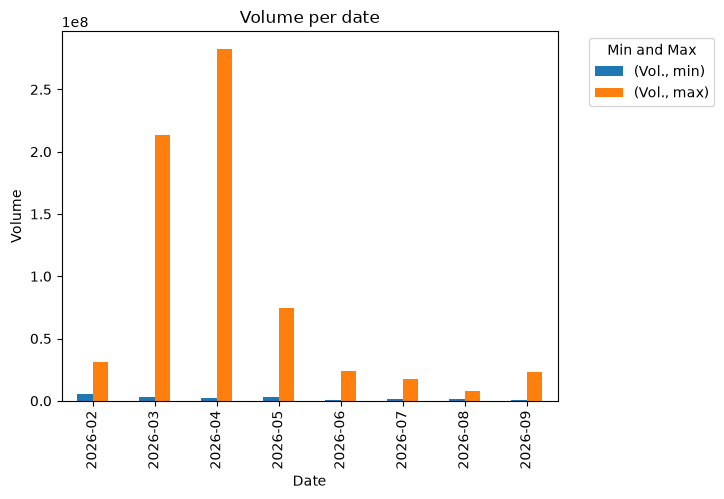

In [37]:
resultsvol.plot(kind = 'bar')

plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Volume per date')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = ('upper left'))
plt.show()

In [39]:
resultsprice = df.groupby(result).agg({
    'Price' : ['min', 'max']
})
resultsprice

Price       
           min    max
Date                 
2026-02  23.95  27.45
2026-03  25.55  27.95
2026-04  25.85  36.00
2026-05  30.35  35.00
2026-06  25.00  33.00
2026-07  25.45  32.00
2026-08  28.00  29.85
2026-09  28.55  32.00

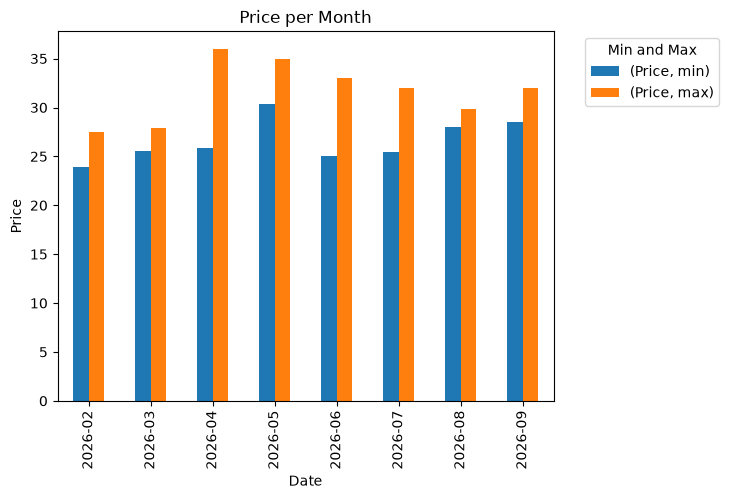

In [40]:
resultsprice.plot(kind = 'bar')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price per Month')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()